In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("./txo_2025-09-17_1334_2025-10_quotes.csv")
df = df[[
    'contract_month', 'underlying_index', 'strike_price',
    'call_last', 'put_last']]
df

,contract_month,underlying_index,strike_price,call_last,put_last
0,2025-10,25432.11,24800,980.0,280.0
1,2025-10,25432.11,24900,905.0,310.0
2,2025-10,25432.11,25000,810.0,333.0
3,2025-10,25432.11,25100,735.0,365.0
4,2025-10,25432.11,25200,670.0,411.0
5,2025-10,25432.11,25300,605.0,432.0
6,2025-10,25432.11,25400,545.0,456.0
7,2025-10,25432.11,25500,486.0,510.0
8,2025-10,25432.11,25600,428.0,550.0
9,2025-10,25432.11,25700,380.0,625.0


# 筆記

## Put-Call Parity
根據 Put-Call Parity 理論及先**不考慮手續費、利率等情況**下，當
> $$現貨指數 - Strike \ne Call- Put$$

表示有套利空間。

## Synthetic Futures / 合成期貨
相同 Strike 的 Options 可以組出等同 Futures 效果的商品，稱為 Synthetic futures。
- 當看多指數時，可以用 `Buy Call +  Sell Put` 的組合，形成同 Long futures 的效果；
- 當看空指數時，可以用 `Sell Call +  Buy Put` 的組合，形成同 Short futures 的效果。

### 兩同向合成期貨存在套利空間
以多頭合成期貨來看，當 $Strike_1(K_1)=45,000$ 與 $Strike_2(K_2)=46,000$ 兩**損益線**（指數 vs Profit）未完全重合時，即表示有套利空間。

#### Box Spread
Box Spread 是由`多頭合成期貨`和`空頭合成期貨`組合的套利策略。

當 $K_2 - K_1 > ((C_2 - P_2) - (C_1 - P_1))$，表示低估市場權利金價值，所以做多$K_1$；做空$K_2$。
- Call 側：Long $K_1$ Call + Short $K_2$ Call
- Put 側：Short $K_1$ Put + Long $K_2$ Put

當 $K_2 - K_1 < ((C_2 - P_2) - (C_1 - P_1))$，表示高估市場權利金價值，所以做空$K_1$；做多$K_2$
- Call 側：Short $K_1$ Call + Long $K_2$ Call
- Put 側：Long $K_1$ Put + Short $K_2$ Put

#### 範例
| Strike | 多頭合成期貨價格 |
| -: | -: |
| $K_1=$ 45,000 | 45,020 |
| $K_2=$ 46,000 | 46,030 |

因為 `46,000- 45,000 < 46,030 - 45,020`，表示高估市場權利金價值，所以做空 45,000；做多46,000
- Call 側：Short 45,000C, Long 46,000C
- Put 側：Long 45,000P, Short 46,000P

#### Long Box & Short Box
| 項目 | Long Box | Short Box |
| - | - | - |
| 合成期貨組合 | 低 K 多頭 + 高 K 空頭 | 低 K 空頭 + 高 K 多頭 |
| Call 側 | Long $K_1$ Call + Short $K_2$ Call | Short $K_1$ Call + Long $K_2$ Call | 
| Put 側 | Short $K_1$ Put + Long $K_2$ Put | Long $K_1$ Put + Short $K_2$ Put | 
| 適用時機 | 合成期貨價差 < 履約價差（低估）| 合成期貨價差 > 履約價差（高估）| 
| 現金流 | 淨支出（需先投入資金）| 淨收入（先收取權利金）|

# 題目一：
> 用履約價相同的買賣權，可以組合出等同
於直接放空此指數的商品。而若兩個不同
履約價組出之商品損益曲線不完全重合，
即會產生套利空間，試從此報價資料中找
到一組套利空間，請將此兩條獲利曲線繪
在同一張圖上並將圖貼到報告中，另說明
該如何買賣這些選擇權且獲得多少套利空
間（假設無交易成本，亦無滑價或流動性
問題） ），試解釋此套利機會可能無法實現
的原因 。

## 可套利組合

| $K_1$ | $K_2$ |
|---:|---|
| 24800 | 24900、25000、25100、25200、25300、25400、25500、25600、25700、25800、25900、26000、26100 |
| 24900 | 25000、25100、25200、25300、25400、25500、25600、25700、25800、25900、26000、26100 |
| 25000 | 25100、25200、25300、25500、25700、25800、25900、26000、26100 |
| 25100 | 25200、25700、25800、25900、26000、26100 |
| 25200 | 25700、25800、25900、26000 |
| 25300 | 25700、25800、25900、26000、26100 |
| 25400 | 25500、25600、25700、25800、25900、26000、26100 |
| 25500 | 25700、25800、25900、26000、26100 |
| 25600 | 25700、25800、25900、26000、26100 |
| 25700 | 25800、25900 |
| 25800 | 25900 |

以 call_last / put_last 為 premium，可以執行套利的組合如上。

以 $K_1=25,800$, $K_2=25,900$ 為例：

$K_1=25,800$ 組成空頭合成期貨，Sell 25800 Call + Buy 25800 Put，$Premium=327-685=-358$

$K_2=25,900$ 組成多頭合成期貨，Buy 25900 Call + Sell 25900 Put，$Premium=-283 + 745=462$

點數差為$25,900 - 25,800 = 100$，$Net\ premium=-358+462=+104$，兩者不相等，所以可套利 $104-100=+4$

Net premium received: +104 points
Fixed box payoff at expiration: -100 points
Locked arbitrage profit: +4 points
Dashed payoff components: blue = long synthetic future (K=25,900); orange = short synthetic future (K=25,800).


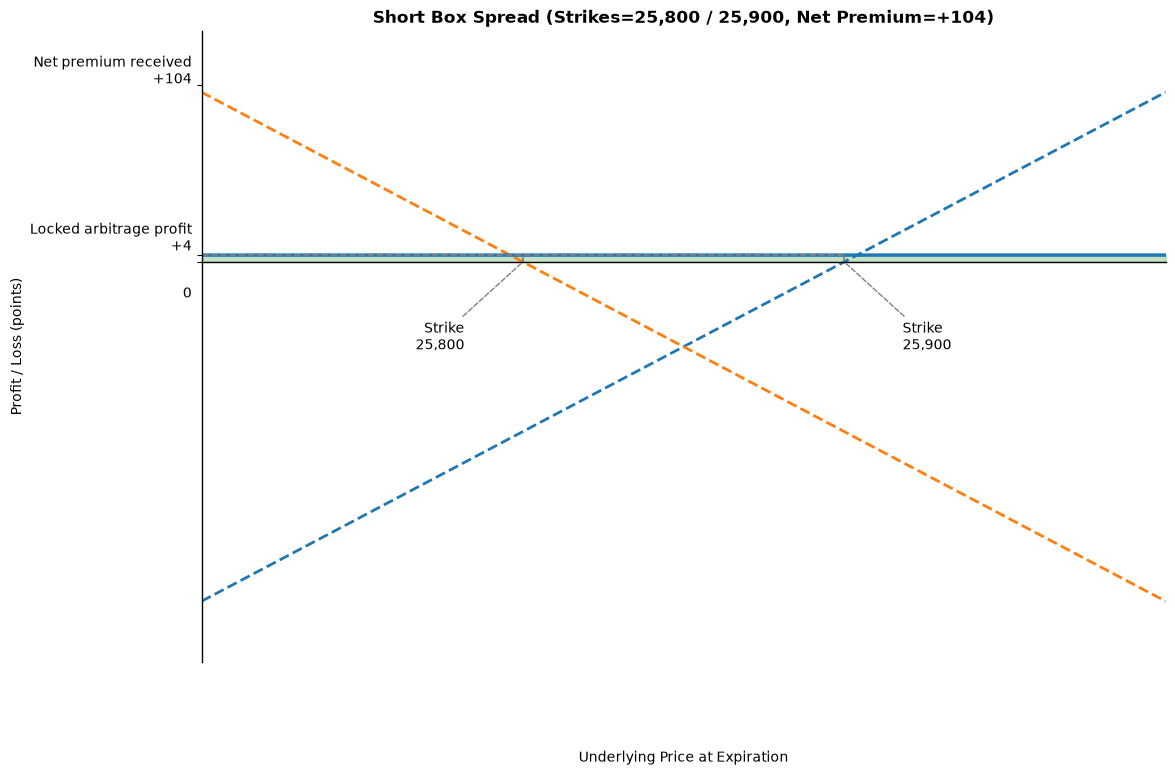

In [15]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.transforms import ScaledTranslation

# Short box: sell C(K1), buy P(K1), buy C(K2), sell P(K2).
k1, k2 = 25_800, 25_900
quote_columns = ['strike_price', 'call_last', 'put_last']
box_quotes = df.loc[df['strike_price'].isin([k1, k2]), quote_columns].copy()
if set(box_quotes['strike_price']) != {k1, k2}:
    raise ValueError('Both 25,800 and 25,900 strikes are required for the short box.')

k1_quote = box_quotes.loc[box_quotes['strike_price'].eq(k1)].iloc[0]
k2_quote = box_quotes.loc[box_quotes['strike_price'].eq(k2)].iloc[0]
sell_call_k1 = float(k1_quote['call_last'])
buy_put_k1 = float(k1_quote['put_last'])
buy_call_k2 = float(k2_quote['call_last'])
sell_put_k2 = float(k2_quote['put_last'])

net_premium = sell_call_k1 - buy_put_k1 - buy_call_k2 + sell_put_k2
box_payoff = -(k2 - k1)
locked_profit = net_premium + box_payoff

# The dashed synthetic futures are payoff-only, so each crosses zero at its strike.
# Their premiums are accounted for separately in the short-box P/L.
expiration_prices = np.linspace(k1 - 100, k2 + 100, 2_001)
short_synthetic_payoff = (
    -np.maximum(expiration_prices - k1, 0)
    + np.maximum(k1 - expiration_prices, 0)
)
long_synthetic_payoff = (
    np.maximum(expiration_prices - k2, 0)
    - np.maximum(k2 - expiration_prices, 0)
)
pnl = short_synthetic_payoff + long_synthetic_payoff + net_premium

# A short box has the same result below, between, and above its strikes.
assert np.allclose(pnl, locked_profit), 'Short-box payoff should be constant at expiration.'
assert np.isclose(np.interp(k1, expiration_prices, short_synthetic_payoff), 0), \
    'The short synthetic future must cross zero at K1.'
assert np.isclose(np.interp(k2, expiration_prices, long_synthetic_payoff), 0), \
    'The long synthetic future must cross zero at K2.'
assert np.isclose(net_premium, 104), f'Expected +104 premium, got {net_premium:+.0f}'
assert np.isclose(locked_profit, 4), f'Expected +4 locked profit, got {locked_profit:+.0f}'
print(f'Net premium received: {net_premium:+,.0f} points')
print(f'Fixed box payoff at expiration: {box_payoff:+,.0f} points')
print(f'Locked arbitrage profit: {locked_profit:+,.0f} points')
print('Dashed payoff components: blue = long synthetic future (K=25,900); '
      'orange = short synthetic future (K=25,800).')


def _distance_between_boxes(first, second):
    dx = max(first.x0 - second.x1, second.x0 - first.x1, 0)
    dy = max(first.y0 - second.y1, second.y0 - first.y1, 0)
    return float(np.hypot(dx, dy))


def _trim_path_near_anchor(path, anchor, radius=5):
    """Ignore the permitted leader/axis contact at an annotation anchor."""
    vertices = path.vertices
    keep = np.hypot(vertices[:, 0] - anchor[0], vertices[:, 1] - anchor[1]) > radius
    trimmed = vertices[keep]
    return Path(trimmed) if len(trimmed) > 1 else None


def place_annotations_without_overlap(ax, specs, pnl_line, profit_fill, guides, component_lines):
    """Globally select rendered annotation candidates with zero geometric collisions."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    protected_paths = [(pnl_line.get_path().transformed(pnl_line.get_transform()), False)]
    protected_paths.extend(
        (line.get_path().transformed(line.get_transform()), False)
        for line in component_lines
    )
    protected_paths.extend(
        (path.transformed(profit_fill.get_transform()), True)
        for path in profit_fill.get_paths()
    )
    for guide in guides:
        protected_paths.extend(
            (path.transformed(guide.get_transform()), False)
            for path in guide.get_paths()
        )
    for spine_name in ('left', 'bottom'):
        spine = ax.spines[spine_name]
        protected_paths.append((spine.get_path().transformed(spine.get_transform()), False))

    static_text = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        text.get_window_extent(renderer).expanded(1.08, 1.16)
        for text in static_text if text.get_visible() and text.get_text()
    ]
    directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
    offsets = [(sx * distance, sy * distance)
               for distance in (42, 64, 88) for sx, sy in directions]

    def make_annotation(text, price, offset):
        return ax.annotate(
            text, xy=(price, 0), xytext=offset, textcoords='offset points',
            ha='left' if offset[0] > 0 else 'right',
            va='bottom' if offset[1] > 0 else 'top',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=1.5),
            arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1),
        )

    candidates = []
    for text, price in specs:
        anchor = ax.transData.transform((price, 0))
        label_candidates = []
        for offset in offsets:
            annotation = make_annotation(text, price, offset)
            fig.canvas.draw()
            bbox = annotation.get_bbox_patch().get_window_extent(renderer).expanded(1.08, 1.16)
            arrow = annotation.arrow_patch.get_path().transformed(annotation.arrow_patch.get_transform())
            trimmed_arrow = _trim_path_near_anchor(arrow, anchor)
            canvas_hit = not (fig.bbox.contains(bbox.x0, bbox.y0)
                              and fig.bbox.contains(bbox.x1, bbox.y1))
            bbox_hits = sum(path.intersects_bbox(bbox, filled=filled)
                            for path, filled in protected_paths)
            text_hits = sum(bbox.overlaps(other) for other in static_boxes)
            leader_hits = 0 if trimmed_arrow is None else sum(
                trimmed_arrow.intersects_path(path, filled=filled)
                for path, filled in protected_paths
            ) + sum(trimmed_arrow.intersects_bbox(other) for other in static_boxes)
            clearance = min(
                [_distance_between_boxes(bbox, path.get_extents())
                 for path, _ in protected_paths] +
                [_distance_between_boxes(bbox, other) for other in static_boxes],
                default=20,
            )
            label_candidates.append({
                'offset': offset, 'bbox': bbox, 'arrow': arrow,
                'trimmed_arrow': trimmed_arrow,
                'collisions': int(canvas_hit) + bbox_hits + text_hits + leader_hits,
                'clearance_shortfall': max(0, 12 - clearance),
            })
            annotation.remove()
        candidates.append(label_candidates)

    def pair_score(first, second):
        collisions = int(first['bbox'].overlaps(second['bbox']))
        collisions += int(first['arrow'].intersects_bbox(second['bbox']))
        collisions += int(second['arrow'].intersects_bbox(first['bbox']))
        if first['trimmed_arrow'] is not None and second['trimmed_arrow'] is not None:
            collisions += int(first['trimmed_arrow'].intersects_path(second['trimmed_arrow']))
        distance = _distance_between_boxes(first['bbox'], second['bbox'])
        return collisions, max(0, 16 - distance)

    best_choice = best_score = None
    for choice in itertools.product(range(len(offsets)), repeat=len(specs)):
        selected = [candidates[index][candidate] for index, candidate in enumerate(choice)]
        collisions = sum(item['collisions'] for item in selected)
        clearance_shortfall = sum(item['clearance_shortfall'] for item in selected)
        label_gap_shortfall = 0
        for first, second in itertools.combinations(selected, 2):
            pair_collisions, pair_shortfall = pair_score(first, second)
            collisions += pair_collisions
            label_gap_shortfall += pair_shortfall
        leader_length = sum(np.hypot(*item['offset']) for item in selected)
        score = (collisions, clearance_shortfall, label_gap_shortfall, leader_length)
        if best_score is None or score < best_score:
            best_choice, best_score = choice, score

    if best_score is None or best_score[0] != 0:
        raise RuntimeError('No collision-free annotation layout found; expand margins or offsets.')

    annotations = [
        make_annotation(text, price, candidates[index][best_choice[index]]['offset'])
        for index, (text, price) in enumerate(specs)
    ]
    return annotations


fig, ax = plt.subplots(figsize=(12, 8))
# Dashed components expose the two synthetic futures that form the box.
long_synthetic_line, = ax.plot(expiration_prices, long_synthetic_payoff, color='tab:blue',
                                    linestyle='--', linewidth=2.0)
short_synthetic_line, = ax.plot(expiration_prices, short_synthetic_payoff, color='tab:orange',
                                     linestyle='--', linewidth=2.0)
pnl_line, = ax.plot(expiration_prices, pnl, color='tab:blue', linewidth=2.5)
profit_fill = ax.fill_between(expiration_prices, 0, pnl, where=pnl > 0,
                              interpolate=True, color='forestgreen', alpha=0.25)

# Finite guides: strike-to-P/L verticals and the locked-profit height.
guide_artists = []
for strike in (k1, k2):
    strike_pnl = float(np.interp(strike, expiration_prices, pnl))
    guide_artists.append(ax.vlines(strike, 0, strike_pnl, color='gray',
                                 linestyle='--', linewidth=1.25))
guide_artists.append(ax.hlines(locked_profit, expiration_prices.min(), k2,
                               color='gray', linestyle='--', linewidth=1.25))

ax.set_xlim(expiration_prices.min(), expiration_prices.max())
component_min = min(short_synthetic_payoff.min(), long_synthetic_payoff.min())
component_max = max(short_synthetic_payoff.max(), long_synthetic_payoff.max())
component_padding = 0.12 * (component_max - component_min)
y_lower = component_min - component_padding
y_upper = component_max + component_padding
ax.set_ylim(y_lower, y_upper)
ax.set_xticks([])
ax.set_yticks([0, locked_profit, net_premium],
              ['0', f'Locked arbitrage profit\n{locked_profit:+,.0f}',
               f'Net premium received\n{net_premium:+,.0f}'])
# Keep the nearby 0 and +4 labels legible after expanding the component range.
zero_tick, locked_profit_tick, net_premium_tick = ax.get_yticklabels()
zero_tick.set_verticalalignment('top')
zero_tick.set_transform(
    zero_tick.get_transform() + ScaledTranslation(0, -18 / 72, fig.dpi_scale_trans)
)
locked_profit_tick.set_verticalalignment('bottom')
net_premium_tick.set_transform(
    net_premium_tick.get_transform() + ScaledTranslation(0, 12 / 72, fig.dpi_scale_trans)
)
ax.set_title('Short Box Spread (Strikes=25,800 / 25,900, Net Premium=+104)',
             fontweight='bold')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', length=0)
ax.xaxis.set_label_coords(0.5, -0.14)
fig.tight_layout(pad=1.6)

annotations = place_annotations_without_overlap(
    ax,
    [(f'Strike\n{k1:,.0f}', k1), (f'Strike\n{k2:,.0f}', k2)],
    pnl_line, profit_fill, guide_artists,
    [long_synthetic_line, short_synthetic_line],
)
fig.tight_layout(pad=1.6)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
for artist in [*annotations, *ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]:
    box = (artist.get_bbox_patch().get_window_extent(renderer)
           if artist in annotations else artist.get_window_extent(renderer))
    assert fig.bbox.contains(box.x0, box.y0) and fig.bbox.contains(box.x1, box.y1), \
        'A chart label extends beyond the figure canvas.'
static_boxes = [artist.get_window_extent(renderer) for artist in
                [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]]
assert not any(first.overlaps(second) for index, first in enumerate(static_boxes)
               for second in static_boxes[index + 1:]), 'Static chart text overlaps.'
plt.show()


## Short Box 
- 最小套利組合：25,000 / 25,500
- 最大套利組合：24,800 / 25,900

### 最大套利組合：24,800 / 25,900
Long 25,900, Short 24,800

- Call 側：Sell 24,800C；Buy 25,900C
- Put 側：Buy 24,800P；Sell 25,900P

$指數差=25,900-24,800=1,100$

$進場現金流=C_1-P_1-C_2+P_2=(980-280)+(-283+745)=+1,162$

$可套利=1,162-1,100=+62$

### 最小套利組合：25,000 / 25,500
Long 25,500, Short 25,000

- Call 側：Sell 25,000C；Buy 25,500C
- Put 側：Buy 25,000P；Sell 25,500P

$指數差=25,500-25,000=500$

$進場現金流=C_1-P_1-C_2+P_2=(810-333)+(-486+510)+=+501$

$可套利=501-500=+1$


In [16]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.transforms import Bbox, ScaledTranslation


def _display_paths(artist):
    """Return an artist's paths in rendered (display) coordinates."""
    return [path.transformed(artist.get_transform()) for path in artist.get_paths()]


def _trim_path_at_anchor(path, anchor, radius=7):
    """The annotation leader may touch only at its own anchor."""
    vertices = path.vertices
    keep = np.hypot(vertices[:, 0] - anchor[0], vertices[:, 1] - anchor[1]) > radius
    trimmed = vertices[keep]
    return Path(trimmed) if len(trimmed) > 1 else None


def _box_distance(first, second):
    dx = max(first.x0 - second.x1, second.x0 - first.x1, 0)
    dy = max(first.y0 - second.y1, second.y0 - first.y1, 0)
    return float(np.hypot(dx, dy))


def _path_box_distance(path, bbox):
    """Minimum display-coordinate distance from a polyline to a text box."""
    if path.intersects_bbox(bbox, filled=False):
        return 0.0
    corners = np.array([
        [bbox.x0, bbox.y0], [bbox.x0, bbox.y1],
        [bbox.x1, bbox.y0], [bbox.x1, bbox.y1],
    ])
    best = np.inf
    for start, end in zip(path.vertices[:-1], path.vertices[1:]):
        segment = end - start
        length_sq = float(segment @ segment)
        if length_sq == 0:
            best = min(best, _box_distance(
                Bbox.from_extents(*start, *start), bbox
            ))
            continue
        t = np.clip(((corners - start) @ segment) / length_sq, 0, 1)
        closest = start + t[:, None] * segment
        best = min(best, float(np.min(np.linalg.norm(corners - closest, axis=1))))
    return best


def _move_nearby_tick_labels(fig, ax, values):
    """Keep required but closely-spaced y tick labels readable."""
    labels = ax.get_yticklabels()
    positions = ax.get_yticks()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for left, right in zip(range(len(labels) - 1), range(1, len(labels))):
        first = labels[left].get_window_extent(renderer)
        second = labels[right].get_window_extent(renderer)
        if first.overlaps(second):
            direction = -1 if positions[left] < positions[right] else 1
            labels[left].set_transform(
                labels[left].get_transform()
                + ScaledTranslation(0, direction * 11 / 72, fig.dpi_scale_trans)
            )
            labels[right].set_transform(
                labels[right].get_transform()
                - ScaledTranslation(0, direction * 11 / 72, fig.dpi_scale_trans)
            )
            fig.canvas.draw()


def _place_annotations_globally(ax, specs, protected):
    """Choose a collision-free annotation layout from all candidate combinations."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    static_artists = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        artist.get_window_extent(renderer).padded(4)
        for artist in static_artists if artist.get_visible() and artist.get_text()
    ]
    directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
    offsets = [
        (horizontal * distance, vertical * distance)
        for distance in (38, 62, 90)
        for horizontal, vertical in directions
    ]

    def make_annotation(text, price, offset):
        return ax.annotate(
            text, xy=(price, 0), xytext=offset, textcoords='offset points',
            ha='left' if offset[0] > 0 else 'right',
            va='bottom' if offset[1] > 0 else 'top', clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.88, pad=1.7),
            arrowprops=dict(
                arrowstyle='-', color='gray', linestyle='--', linewidth=1,
                shrinkA=0, shrinkB=0, connectionstyle='arc3,rad=0',
            ),
        )

    candidates = []
    for text, price in specs:
        anchor = ax.transData.transform((price, 0))
        choices = []
        for offset in offsets:
            annotation = make_annotation(text, price, offset)
            fig.canvas.draw()
            bbox = annotation.get_bbox_patch().get_window_extent(renderer).padded(3)
            arrow = annotation.arrow_patch.get_path().transformed(annotation.arrow_patch.get_transform())
            trimmed_arrow = _trim_path_at_anchor(arrow, anchor)
            collisions = int(not (
                fig.bbox.contains(bbox.x0, bbox.y0) and fig.bbox.contains(bbox.x1, bbox.y1)
            ))
            collisions += sum(path.intersects_bbox(bbox, filled=filled)
                              for path, filled in protected)
            collisions += sum(bbox.overlaps(other) for other in static_boxes)
            arrow_collisions = 0 if trimmed_arrow is None else (
                sum(trimmed_arrow.intersects_path(path, filled=filled)
                    for path, filled in protected)
                + sum(trimmed_arrow.intersects_bbox(other) for other in static_boxes)
            )
            collisions += arrow_collisions
            distances = [_path_box_distance(path, bbox) for path, _ in protected]
            distances.extend(_box_distance(bbox, other) for other in static_boxes)
            choices.append({
                'offset': offset, 'bbox': bbox, 'arrow': arrow,
                'trimmed_arrow': trimmed_arrow, 'collisions': int(collisions),
                'line_shortfall': max(0, 10 - min(distances, default=20)),
            })
            annotation.remove()
        candidates.append(choices)

    best_choice = best_score = None
    for choice in itertools.product(range(len(offsets)), repeat=len(specs)):
        selected = [candidates[index][candidate] for index, candidate in enumerate(choice)]
        collisions = sum(item['collisions'] for item in selected)
        line_shortfall = sum(item['line_shortfall'] for item in selected)
        label_shortfall = 0
        for first, second in itertools.combinations(selected, 2):
            collisions += int(first['bbox'].overlaps(second['bbox']))
            collisions += int(first['arrow'].intersects_bbox(second['bbox']))
            collisions += int(second['arrow'].intersects_bbox(first['bbox']))
            if first['trimmed_arrow'] is not None and second['trimmed_arrow'] is not None:
                collisions += int(first['trimmed_arrow'].intersects_path(second['trimmed_arrow']))
            label_shortfall += max(0, 16 - _box_distance(first['bbox'], second['bbox']))
        leader_length = sum(np.hypot(*item['offset']) for item in selected)
        score = (collisions, line_shortfall, label_shortfall, leader_length)
        if best_score is None or score < best_score:
            best_choice, best_score = choice, score
    if best_score is None or best_score[0] != 0:
        raise RuntimeError('No collision-free label layout; enlarge the chart or margins.')
    return [
        make_annotation(text, price, candidates[index][best_choice[index]]['offset'])
        for index, (text, price) in enumerate(specs)
    ]


def _validate_final_layout(fig, ax, annotations, protected):
    """Use rendered geometry to reject any final collision or clipping."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    static_artists = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        artist.get_window_extent(renderer).padded(3)
        for artist in static_artists if artist.get_visible() and artist.get_text()
    ]
    for box in static_boxes:
        assert fig.bbox.contains(box.x0, box.y0) and fig.bbox.contains(box.x1, box.y1), \
            'Static chart text extends beyond the canvas.'
    assert not any(first.overlaps(second) for index, first in enumerate(static_boxes)
                   for second in static_boxes[index + 1:]), 'Static chart text overlaps.'
    annotation_boxes = []
    for annotation in annotations:
        bbox = annotation.get_bbox_patch().get_window_extent(renderer).padded(3)
        assert fig.bbox.contains(bbox.x0, bbox.y0) and fig.bbox.contains(bbox.x1, bbox.y1), \
            'An annotation extends beyond the canvas.'
        assert not any(path.intersects_bbox(bbox, filled=filled) for path, filled in protected), \
            'An annotation overlaps a plotted line, guide, axis, or profit area.'
        assert not any(bbox.overlaps(other) for other in static_boxes), \
            'An annotation overlaps static chart text.'
        annotation_boxes.append(bbox)
    for first, second in itertools.combinations(annotation_boxes, 2):
        assert not first.overlaps(second), 'Annotations overlap.'


def plot_short_box(strategy_name, k1, k2):
    """Plot any short box using only the quoted last premiums in ``df``."""
    quotes = df.set_index('strike_price')
    c1, p1 = quotes.loc[k1, ['call_last', 'put_last']].astype(float)
    c2, p2 = quotes.loc[k2, ['call_last', 'put_last']].astype(float)
    net_premium = c1 - p1 - c2 + p2
    locked_profit = net_premium - (k2 - k1)
    assert locked_profit > 0, 'This helper is intended for an arbitrage short box.'

    horizontal_pad = max(250, 0.22 * (k2 - k1))
    prices = np.linspace(k1 - horizontal_pad, k2 + horizontal_pad, 2_001)
    pnl = np.full_like(prices, locked_profit, dtype=float)
    # The dashed legs are payoff-only synthetic futures; premiums stay in ``pnl``.
    long_synthetic = prices - k2
    short_synthetic = k1 - prices
    component_floor = min(long_synthetic.min(), short_synthetic.min())
    component_ceiling = max(long_synthetic.max(), short_synthetic.max())
    ymax = max(net_premium, locked_profit, component_ceiling, 1) * 1.16
    ymin = min(component_floor * 1.16, -max(net_premium, locked_profit, 1) * 0.66)

    fig, ax = plt.subplots(figsize=(13, 9))
    # Buy C(K2) + sell P(K2): long synthetic future; sell C(K1) + buy P(K1): short.
    long_synthetic_line, = ax.plot(
        prices, long_synthetic, color='tab:blue', linestyle='--', linewidth=2.0, zorder=2
    )
    short_synthetic_line, = ax.plot(
        prices, short_synthetic, color='tab:orange', linestyle='--', linewidth=2.0, zorder=2
    )
    pnl_line, = ax.plot(prices, pnl, color='tab:blue', linewidth=2.5, zorder=3)
    profit_fill = ax.fill_between(
        prices, 0, pnl, where=pnl > 0, interpolate=True,
        color='forestgreen', alpha=0.25, zorder=1,
    )
    guides = [
        ax.vlines(strike, 0, locked_profit, color='gray', linestyle='--', linewidth=1.1, zorder=2)
        for strike in (k1, k2)
    ]
    guides.append(ax.hlines(locked_profit, prices.min(), k2, color='gray',
                            linestyle='--', linewidth=1.1, zorder=2))

    ax.set_xlim(prices.min(), prices.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    tick_values = [0, locked_profit, net_premium]
    tick_labels = [
        '0', f'Locked arbitrage profit\n{locked_profit:+,.0f}',
        f'Net premium received\n{net_premium:+,.0f}',
    ]
    ax.set_yticks(tick_values, tick_labels)
    ax.set_title(f'{strategy_name} (Strikes={k1:,.0f} / {k2:,.0f}, Net Premium={net_premium:+,.0f})')
    ax.set_xlabel('Underlying Price at Expiration')
    ax.set_ylabel('Profit / Loss (points)')
    ax.yaxis.set_label_coords(-0.24, 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', length=0)
    ax.xaxis.set_label_coords(0.5, -0.16)
    fig.tight_layout(pad=1.8)
    _move_nearby_tick_labels(fig, ax, tick_values)

    protected = [
        (pnl_line.get_path().transformed(pnl_line.get_transform()), False),
        *[(path, True) for path in _display_paths(profit_fill)],
        *[(path, False) for guide in guides for path in _display_paths(guide)],
        (long_synthetic_line.get_path().transformed(long_synthetic_line.get_transform()), False),
        (short_synthetic_line.get_path().transformed(short_synthetic_line.get_transform()), False),
        (ax.spines['left'].get_path().transformed(ax.spines['left'].get_transform()), False),
        (ax.spines['bottom'].get_path().transformed(ax.spines['bottom'].get_transform()), False),
    ]
    annotations = _place_annotations_globally(
        ax, [(f'Strike\n{k1:,.0f}', k1), (f'Strike\n{k2:,.0f}', k2)], protected
    )
    fig.canvas.draw()
    _validate_final_layout(fig, ax, annotations, protected)
    plt.show()


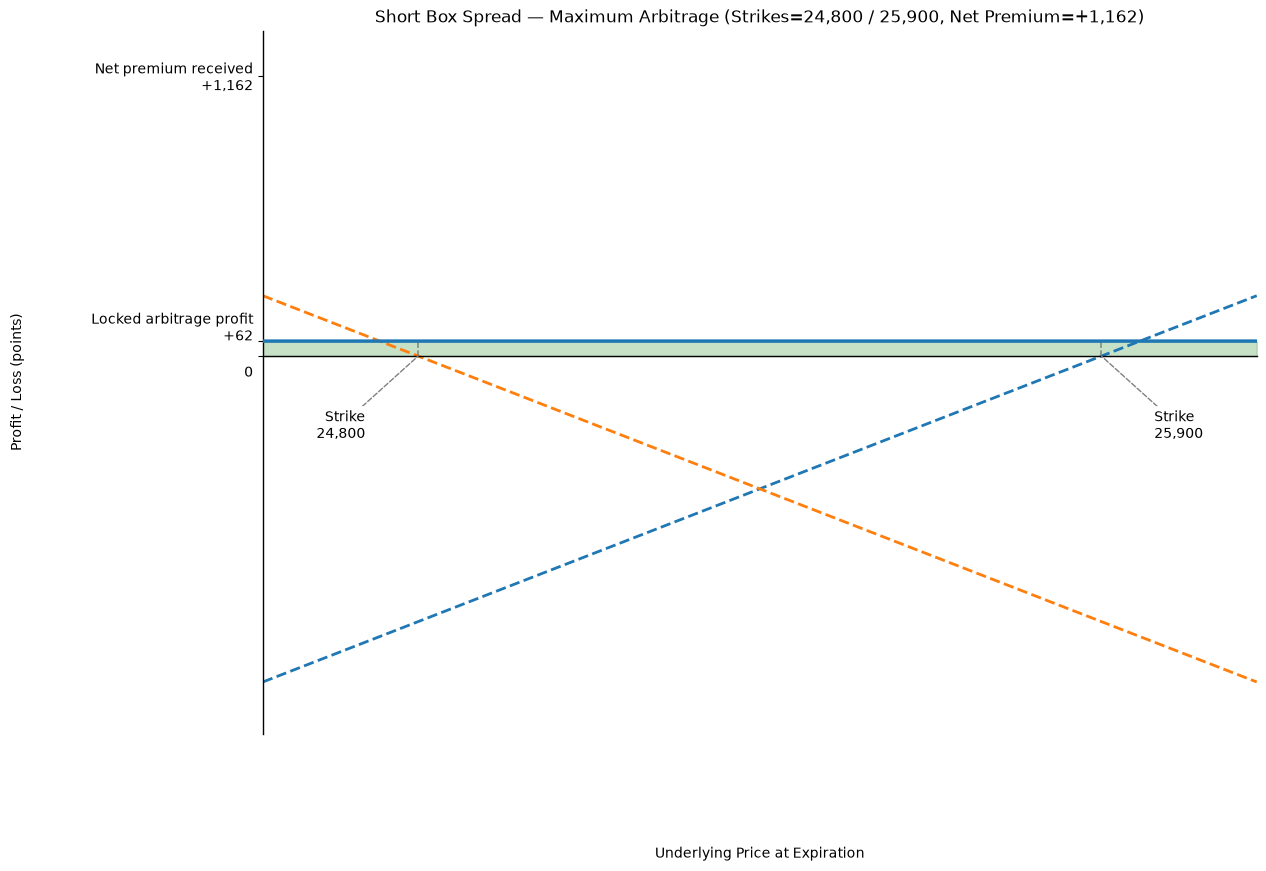

In [17]:
# Maximum arbitrage short box: 24,800 / 25,900.
plot_short_box('Short Box Spread — Maximum Arbitrage', 24_800, 25_900)


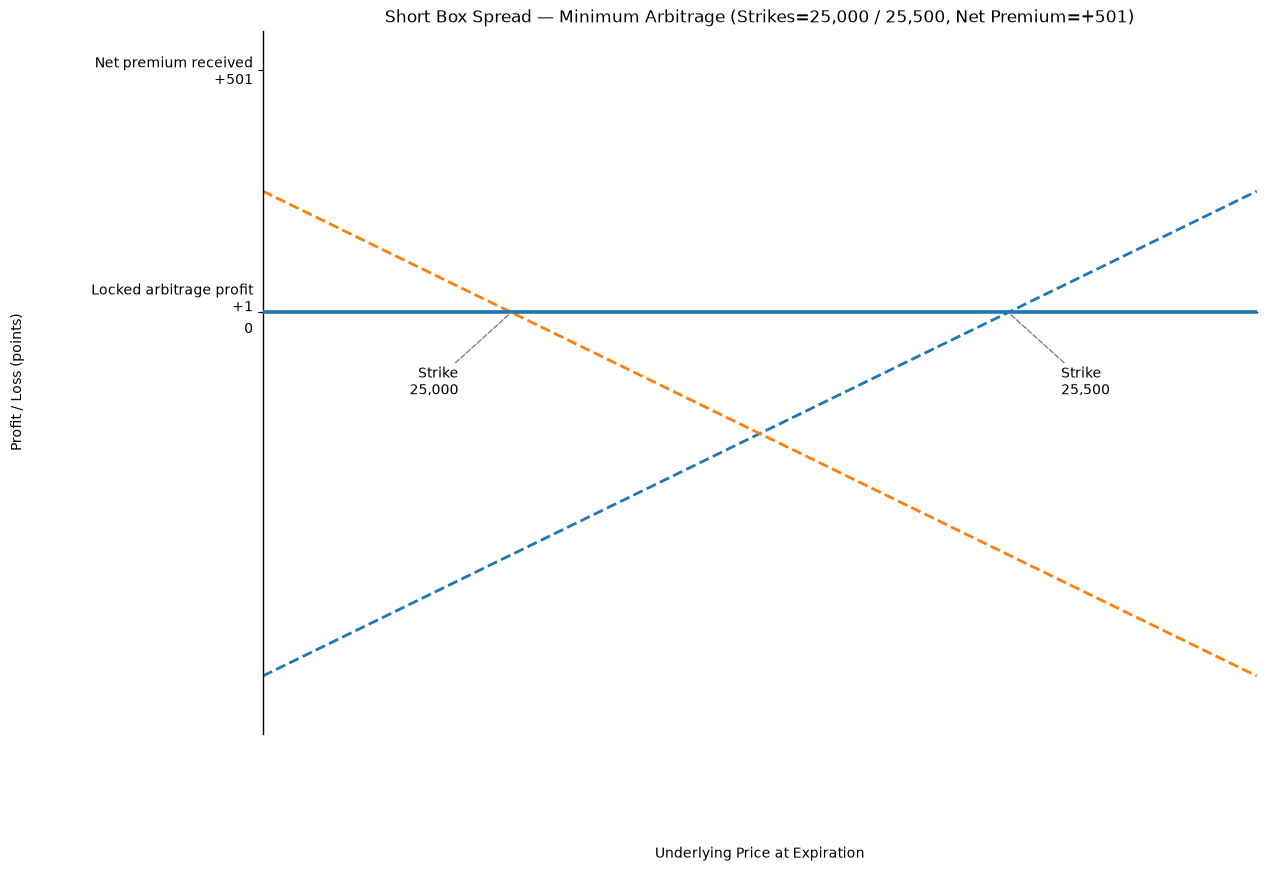

In [18]:
# Minimum arbitrage short box: 25,000 / 25,500.
plot_short_box('Short Box Spread — Minimum Arbitrage', 25_000, 25_500)


# 題目二：
> 假設你已知川普必然會在兩週後降低台灣
關稅稅率，使上述選擇權結算時的台灣加
權股價指數上漲．且必然出現在 25,650 點以
上，試組合出兩組不同的 spread 儘可能在符
合上述假設時獲利，請將兩條獲利曲線繪
在同一張圖上並將圖貼到報告中，另在報
告中簡 述你用哪些選擇權組出此組合，並
比較兩組合在各結算價位的優劣。

# 題目三：
> 假設你已知道接下來這個月股價波動劇烈，
結算日時不是大好即是大壞，你很有把握
股價會遠離 25,500 但不確定是大漲還是大跌，
試組合出符合此假設的 strangle 、 straddle 、
butterfly spread ，請將三條獲利曲線繪在同
一張圖上並將圖貼到報告中， 同時解釋三
個組合各由哪些選擇權構成， 另在報告中
簡單比較三組合在各結算價位的優劣。